In [29]:
import sys
import os

# Absolute path to the project root
PROJECT_ROOT = r"C:\Users\Anshul Deep Bajpai\Desktop\Sentiment_Analysis_System"

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(sys.path[0])

import importlib.util

spec = importlib.util.find_spec("scripts")
print(spec)

C:\Users\Anshul Deep Bajpai\Desktop\Sentiment_Analysis_System
ModuleSpec(name='scripts', loader=<_frozen_importlib_external.NamespaceLoader object at 0x000002833D40FBB0>, submodule_search_locations=_NamespacePath(['c:\\Users\\Anshul Deep Bajpai\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\site-packages\\win32\\scripts']))


In [30]:
import importlib.util

spec = importlib.util.find_spec("scripts.preprocess")
print(spec)

None


In [25]:
# from scripts.preprocess import clean_text
import os
print(os.getcwd())
import os

print(os.listdir("../scripts"))

c:\Users\Anshul Deep Bajpai\Desktop\Sentiment_Analysis_System\notebooks
['evaluate_models.py', 'generate_wordcloud.py', 'preprocess.py', 'train_models.py', '__init__.py', '__pycache__']


In [32]:
import sys
import os

sys.path.insert(
    0,
    r"C:\Users\Anshul Deep Bajpai\Desktop\Sentiment_Analysis_System\scripts"
)

from preprocess import clean_text

print(clean_text("This movie was AMAZING!!!"))

[nltk_data] Downloading package stopwords to C:\Users\Anshul Deep
[nltk_data]     Bajpai\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Anshul Deep
[nltk_data]     Bajpai\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


movie amazing


### Import Libraries

In [33]:
import pandas as pd
import joblib

from preprocess import clean_text

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score

In [35]:
df = pd.read_csv(
    "../data/raw/IMDB_Dataset.csv"
)

df["review"] = df["review"].apply(
    clean_text
)

In [36]:
X = df["review"]
y = df["sentiment"]

In [37]:
vectorizer = TfidfVectorizer(
    max_features=5000
)

X = vectorizer.fit_transform(X)

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [39]:
models = {
    "Logistic Regression":
        LogisticRegression(),

    "Naive Bayes":
        MultinomialNB(),

    "Linear SVM":
        LinearSVC()
}


In [40]:
results = {}

for name, model in models.items():

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(
        X_test
    )

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    results[name] = accuracy

In [41]:
results

{'Logistic Regression': 0.8893, 'Naive Bayes': 0.8554, 'Linear SVM': 0.8818}

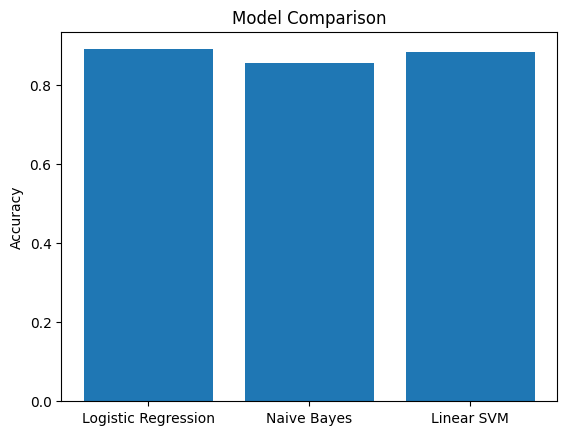

In [42]:
import matplotlib.pyplot as plt

plt.bar(
    results.keys(),
    results.values()
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "Model Comparison"
)

plt.show()